## Modeling - Decision Tree Regressor

Target variable "claim risk":
y = ClaimNb/ Exposure


In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('Project_description_and_data/claims_train.csv')
print(df.head())
print(df.info())

       IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0  2122523.0        0      0.43    D         7      18       36          95   
1  3173420.0        0      0.10    D         7      17       80          95   
2  1188619.0        0      0.33    E         7       3       36          76   
3    31400.0        0      0.56    A         5       4       73          52   
4  3138755.0        0      0.27    E         8       0       37          50   

  VehBrand   VehGas  Density Region  
0       B1  Regular     1054    R24  
1       B2  Regular      598    R25  
2       B6  Regular     4172    R82  
3      B13   Diesel       15    R24  
4      B11   Diesel     3021    R53  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542410 entries, 0 to 542409
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       542410 non-null  float64
 1   ClaimNb     542410 non-null  int64  
 2   Exposure    5

In [ ]:
# Preprocessing
for col in ['VehBrand', 'Area', 'Region']:
    df[col] = df[col].astype('category').cat.codes
df['Density_log'] = np.log(df['Density'] + 1) # avoids log(0)
df['VehGas'] = np.where(df['VehGas'] == 'Regular', 0, 1)
bin_edges_veh = [0, 2, 6, 10, 15, 100]
df['VehAge_bin'] = pd.cut(df['VehAge'], bins=bin_edges_veh, labels=[1, 2, 3, 4, 5], include_lowest=True)
bin_edges_driv = [17, 25, 35, 50, 65, 100]
df['DrivAge_bin'] = pd.cut(df['DrivAge'], bins=bin_edges_driv, labels=[1, 2, 3, 4, 5])

df['claim_rate'] = df['ClaimNb'] / df['Exposure']

features = ['VehBrand', 'VehGas', 'VehPower', 'VehAge_bin', 'DrivAge_bin',
    'Area', 'Region', 'BonusMalus', 'Density_log']

X = df[features].values
y = df['claim_rate'].values

# Split data (using sklearn):
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Split data into train-validation (from-scratch implementation):
# n = len(X)
# np.random.seed(42)
# indices = np.random.permutation(n)
# split = int(0.8 * n)
# train_idx = indices[:split]
# val_idx = indices[split:]
# X_train, y_train = X[train_idx], y[train_idx]
# X_val, y_val = X[val_idx], y[val_idx]

# From-scratch Decision Tree Implementation:
def mse(y):
    return np.mean((y - np.mean(y))**2)
def best_split(X, y, min_samples_split=10):
    best_feature, best_thresh, best_mse = None, None, float('inf')
    n_samples, n_features = X.shape
    
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            left_mask = X[:, feature] <= t
            right_mask = X[:, feature] > t
            if np.sum(left_mask) < min_samples_split or np.sum(right_mask) < min_samples_split:
                continue
            weighted_mse = (len(left_mask)*mse(y[left_mask]) + len(right_mask)*mse(y[right_mask])) / n_samples
            if weighted_mse < best_mse:
                best_feature, best_thresh, best_mse = feature, t, weighted_mse
    return best_feature, best_thresh, best_mse

# Node class
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

# Regression Tree class
class RegressionTree:
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(set(y)) == 1:
            return np.mean(y)
        
        feature, thresh, _ = best_split(X, y, self.min_samples_split)
        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= thresh
        right_mask = ~left_mask

        left_branch = self._build_tree(X[left_mask], y[left_mask], depth+1)
        right_branch = self._build_tree(X[right_mask], y[right_mask], depth+1)

        return Node(feature, thresh, left_branch, right_branch)

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if not isinstance(node, Node):
            return node
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])


# Train and evaluate
tree_scratch = RegressionTree(max_depth=6, min_samples_split=30)
tree_scratch.fit(X_train, y_train)

y_pred_scratch = tree_scratch.predict(X_val)
mse_scratch = np.mean((y_val - y_pred_scratch)**2)
print(f"From-scratch Decision Tree MSE: {mse_scratch:.5f}")


From-scratch Decision Tree MSE: 23.46188


In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Reference sklearn tree
tree_ref = DecisionTreeRegressor(max_depth=6, min_samples_split=30, random_state=42)
tree_ref.fit(X_train, y_train)

y_pred_ref = tree_ref.predict(X_val)
mse_ref = mean_squared_error(y_val, y_pred_ref)

print(f"Sklearn Decision Tree MSE: {mse_ref:.5f}")

# Compare predictions
diff = np.mean(np.abs(y_pred_scratch - y_pred_ref))
print(f"Average absolute difference between scratch & reference: {diff:.5f}")

Sklearn Decision Tree MSE: 23.47555
Average absolute difference between scratch & reference: 0.16585


Decision Tree (Reference Implementation) Results:
   max_depth       MSE        R2
0          3  0.042561  0.262552
1          5  0.042128  0.270051
2          7  0.041968  0.272824
3          9  0.042155  0.269582


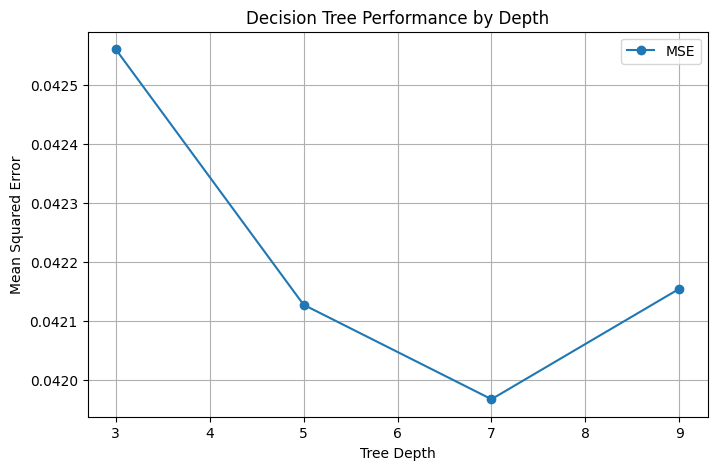

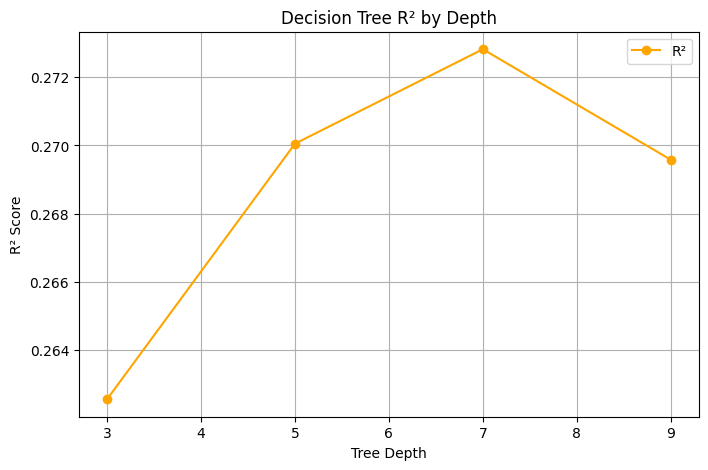

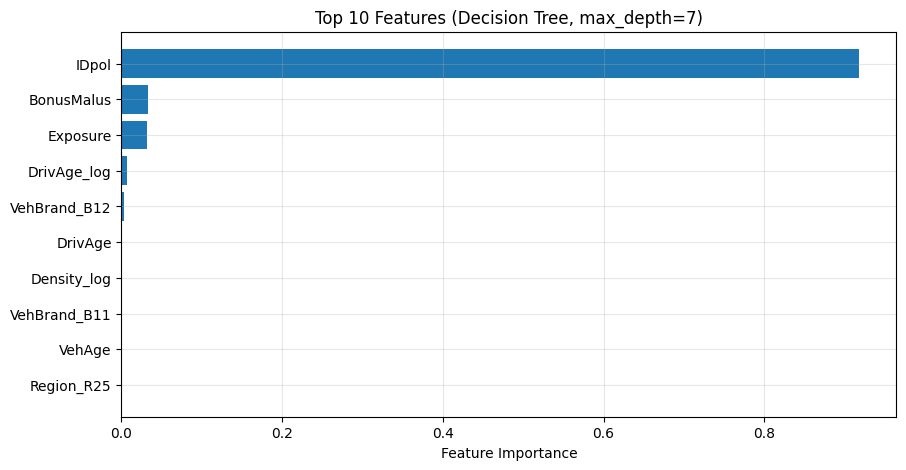


Best Performing Model -> max_depth=7.0
MSE=0.0420, R²=0.2728


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df=pd.read_csv('Project_description_and_data/claims_train.csv')

df['VehAge_1'] = df['VehAge'] + 1
df['VehAge_log'] = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])

categorical_cols = ['VehBrand', 'VehGas', 'Area', 'Region']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(columns=['ClaimNb'])
y = df['ClaimNb']


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

for depth in [3, 5, 7, 9]:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    results.append({'max_depth': depth, 'MSE': mse, 'R2': r2})

    
results_df = pd.DataFrame(results)
print("Decision Tree (Reference Implementation) Results:")
print(results_df)


plt.figure(figsize=(8, 5))
plt.plot(results_df['max_depth'], results_df['MSE'], marker='o', label='MSE')
plt.xlabel('Tree Depth')
plt.ylabel('Mean Squared Error')
plt.title('Decision Tree Performance by Depth')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df['max_depth'], results_df['R2'], marker='o', color='orange', label='R²')
plt.xlabel('Tree Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree R² by Depth')
plt.grid(True)
plt.legend()
plt.show()


best_depth = results_df.loc[results_df['R2'].idxmax(), 'max_depth']
best_model = DecisionTreeRegressor(max_depth=int(best_depth), random_state=42)
best_model.fit(X_train, y_train)

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(importances.index, importances.values)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title(f"Top 10 Features (Decision Tree, max_depth={best_depth})")
plt.grid(alpha=0.3)
plt.show()

best_row = results_df.loc[results_df['R2'].idxmax()]
print(f"\nBest Performing Model -> max_depth={best_row['max_depth']}")
print(f"MSE={best_row['MSE']:.4f}, R²={best_row['R2']:.4f}")

Best Parameters Found:
{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}

Model Performance:
  Train MSE: 0.0415, R²: 0.2693
  Val   MSE: 0.0419, R²: 0.2736



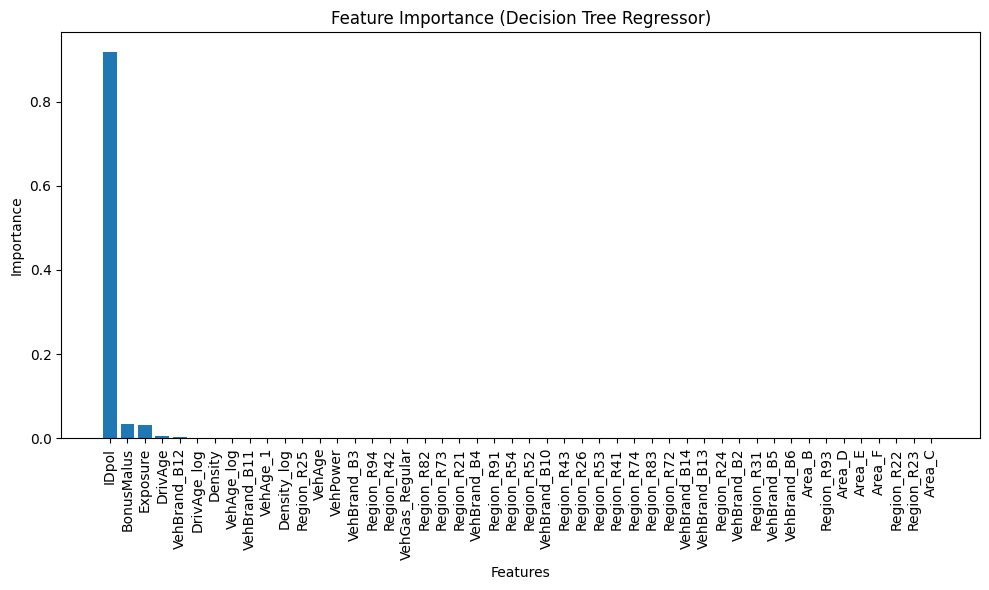

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

df['VehAge_1'] = df['VehAge'] + 1
df['VehAge_log'] = np.log(df['VehAge_1'])
df['DrivAge_log'] = np.log(df['DrivAge'])
df['Density_log'] = np.log(df['Density'])

X = df.drop(columns=['ClaimNb'])
y = df['ClaimNb']

X = pd.get_dummies(X, drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


tree = DecisionTreeRegressor(random_state=42)
param_grid = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters Found:")
print(grid_search.best_params_)
print()


best_tree = grid_search.best_estimator_

y_train_pred = best_tree.predict(X_train)
y_val_pred = best_tree.predict(X_val)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("Model Performance:")
print(f"  Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"  Val   MSE: {val_mse:.4f}, R²: {val_r2:.4f}")
print()


importances = best_tree.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.title('Feature Importance (Decision Tree Regressor)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

